# 01 — Quick start: using the emulators without `cloelib`

This notebook shows how to load and evaluate the released CosmoPower-JAX emulators directly, with nothing but
`cosmopower-jax`, `numpy` and `matplotlib`:

```bash
pip install cosmopower-jax matplotlib      # tested with cosmopower-jax 0.5.8
```

What is covered:

1. what is inside an emulator file and how to load it;
2. linear and nonlinear $P(k,z)$ for ΛCDM;
3. total matter $P_{\rm mm}$ versus cold dark matter + baryons $P_{\rm cb}$;
4. the scalar emulators: $\sigma_8(z)$, $f\sigma_8(z)$, and the growth factor;
5. evaluating on your own $k$ grid;
6. batch evaluation and speed;
7. derivatives with respect to the cosmological parameters (JAX autodiff);
8. staying inside the training box.

The other notebooks tour the model families (`02`), the beyond-ΛCDM emulators (`03`) and the `cloelib` interface (`04`).
All paths are relative to the repository root; run the notebook from the `notebooks/` folder.

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX

# The notebooks live in notebooks/, the emulators one level up.
EMU_DIR = next(p for p in ["../emulators", "emulators"] if os.path.isdir(p))

def load(relpath, probe="custom_log"):
    """Load one emulator file.
    probe='custom_log' : P(k) emulators, MG boosts and the DDM distances file (they store log10 of the target,
                         predict() returns the de-logged quantity)
    probe='custom'     : sigma8/fsigma8, DDM growth and DDM global emulators (values stored directly)"""
    return CosmoPowerJAX(probe=probe, filepath=os.path.join(EMU_DIR, relpath), verbose=False)

def predict(emu, **params):
    """Evaluate `emu` from keyword inputs. Scalars are broadcast against array-valued inputs,
    keys the emulator does not use are ignored. Returns an array of shape (n_samples, n_outputs)."""
    arrs = {k: np.atleast_1d(np.asarray(v, dtype=float)) for k, v in params.items()}
    missing = [p for p in emu.parameters if p not in arrs]
    if missing:
        raise KeyError(f"missing inputs {missing}; this emulator expects {list(emu.parameters)}")
    n = max(a.size for a in arrs.values())
    inputs = {p: (np.full(n, arrs[p][0]) if arrs[p].size == 1 else arrs[p]) for p in emu.parameters}
    return np.atleast_2d(np.asarray(emu.predict(inputs)))

plt.rcParams.update({"font.size": 11, "figure.dpi": 100})

# Planck-2018-like fiducial point, in the parameter names used by the CAMB-family emulators
PLANCK = dict(ombh2=0.0224, omch2=0.120, H0=67.4, ns=0.965, lnAs=3.044)
print("emulator directory:", os.path.abspath(EMU_DIR))

emulator directory: /Users/ivan/Desktop/dr1-matter-emulators/emulators


## 1. What is inside an emulator file

Every `.npz` holds one pickled dictionary in the CosmoPower format: the network weights, the input/output
normalisation, the list of input `parameters`, and the output grid `modes` (the $k$ grid for $P(k)$ emulators,
an output index for the scalar ones). `CosmoPowerJAX` reads it with `filepath=` and a `probe` that tells it
whether the stored target is $\log_{10}$ of the quantity (`custom_log`) or the quantity itself (`custom`).

| Emulator | `probe` | `predict()` returns |
|---|---|---|
| `*-linear`, `*-nonlinear`, `*-cb-linear`, `*-cb-nonlinear` | `custom_log` | $P(k,z)$ in Mpc³ on `modes` (Mpc⁻¹) |
| `mg-boost-*` | `custom_log` | boost $P_{\rm MG}/P_{\Lambda{\rm CDM}}$ on `modes` ($h$/Mpc) |
| `ddm-1body-combined-distances` | `custom_log` | $H(z)$ [Mpc⁻¹], $D_A(z)$, $D_L(z)$ [Mpc] |
| `*-s8-fs8`, `*-s8-fs8`, `ddm-*-growth` | `custom` | $\sigma_8(z)$, $f\sigma_8(z)$ |
| `ddm-1body-combined-global` | `custom` | $\sigma_8$, $\Omega_m$, $r_{\rm drag}$ |

The training ranges themselves are listed in the repository README and in section 8 below.

In [2]:
nl = load("lcdm/hmcode/lcdm-1mass-nonlinear.npz")

print("inputs :", list(nl.parameters))
print("outputs:", len(nl.modes), "k-modes from", f"{float(np.min(nl.modes)):.1e}", "to", f"{float(np.max(nl.modes)):.1f}", "Mpc^-1")

# the raw dictionary, if you want to look under the hood
raw = np.load(os.path.join(EMU_DIR, "lcdm/hmcode/lcdm-1mass-nonlinear.npz"), allow_pickle=True)["arr_0"].item()
print("keys   :", list(raw.keys()))
print("network:", raw["n_hidden"], "hidden layers;", raw["n_layers"], "layers in total")

inputs : ['ombh2', 'omch2', 'H0', 'ns', 'lnAs', 'z', 'mnu', 'logT_AGN']
outputs: 520 k-modes from 1.0e-05 to 49.2 Mpc^-1
keys   : ['weights_', 'biases_', 'alphas_', 'betas_', 'param_train_mean', 'param_train_std', 'feature_train_mean', 'feature_train_std', 'n_parameters', 'parameters', 'n_modes', 'modes', 'n_hidden', 'n_layers', 'architecture']
network: [512, 512, 512, 512] hidden layers; 5 layers in total


## 2. Linear and nonlinear $P(k,z)$ for ΛCDM

Inputs are passed as a dictionary keyed by the names in `emu.parameters`; every value is a 1-D array and the
emulator returns one spectrum per entry. Redshift is an ordinary input, so one call gives $P(k)$ at any set of
redshifts. The nonlinear emulators (HMCode2020) take the AGN feedback temperature `logT_AGN` as an extra input.

The `predict()` helper defined above broadcasts scalars for you, so a cosmology at four redshifts is one line.

shapes: (4, 520) (4, 520)


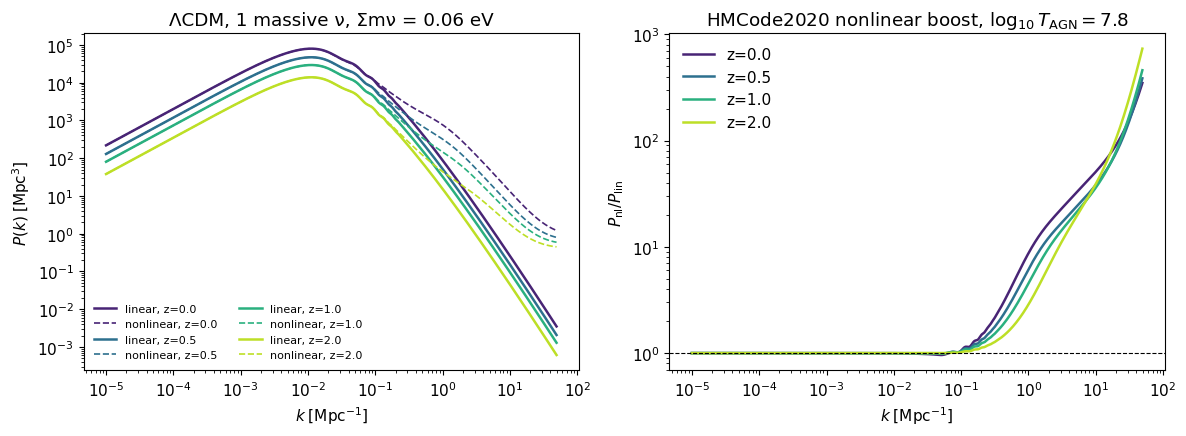

In [3]:
zs = np.array([0.0, 0.5, 1.0, 2.0])
lin = load("lcdm/hmcode/lcdm-1mass-linear.npz")
nl  = load("lcdm/hmcode/lcdm-1mass-nonlinear.npz")
k   = np.asarray(lin.modes)                       # same grid for both

pk_lin = predict(lin, **PLANCK, mnu=0.06, z=zs)                # shape (4, 520)
pk_nl  = predict(nl,  **PLANCK, mnu=0.06, logT_AGN=7.8, z=zs)  # shape (4, 520)
print("shapes:", pk_lin.shape, pk_nl.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(zs)))
for i, (z, c) in enumerate(zip(zs, colors)):
    axes[0].loglog(k, pk_lin[i], color=c, lw=1.8, label=f"linear, z={z}")
    axes[0].loglog(k, pk_nl[i],  color=c, lw=1.2, ls="--", label=f"nonlinear, z={z}")
    axes[1].semilogx(k, pk_nl[i] / pk_lin[i], color=c, lw=1.8, label=f"z={z}")
axes[0].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P(k)\;[\mathrm{Mpc}^3]$", title="ΛCDM, 1 massive ν, Σmν = 0.06 eV")
axes[0].legend(fontsize=8, ncol=2, frameon=False)
axes[1].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm nl}/P_{\rm lin}$", yscale="log", title=r"HMCode2020 nonlinear boost, $\log_{10}T_{\rm AGN}=7.8$")
axes[1].axhline(1, color="k", lw=0.8, ls="--"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## 3. Total matter versus CDM + baryons

With massive neutrinos the total-matter spectrum $P_{\rm mm}$ is suppressed on scales below the neutrino
free-streaming length, while $P_{\rm cb}$ (CDM + baryons, the quantity galaxies trace) is suppressed less.
Both are emulated: the `-cb-linear` / `-cb-nonlinear` files take exactly the same inputs as the total-matter ones.

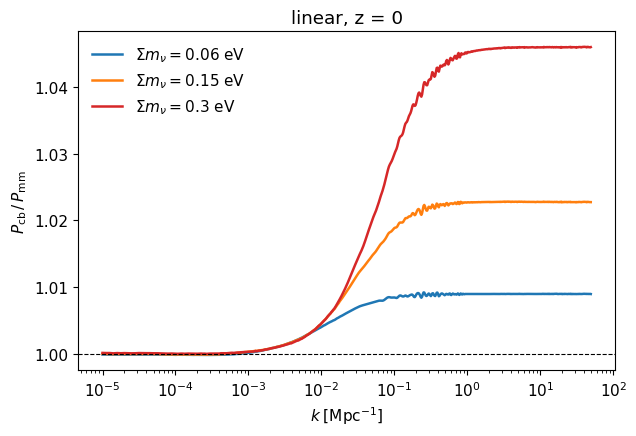

In [4]:
cb = load("lcdm/hmcode/lcdm-1mass-cb-linear.npz")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for mnu, c in zip([0.06, 0.15, 0.30], ["C0", "C1", "C3"]):
    pmm = predict(lin, **PLANCK, mnu=mnu, z=0.0)[0]
    pcb = predict(cb,  **PLANCK, mnu=mnu, z=0.0)[0]
    ax.semilogx(k, pcb / pmm, color=c, lw=1.8, label=rf"$\Sigma m_\nu = {mnu}$ eV")
ax.axhline(1, color="k", lw=0.8, ls="--")
ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm cb}\,/\,P_{\rm mm}$", title="linear, z = 0")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 4. Scalar emulators: $\sigma_8(z)$, $f\sigma_8(z)$ and the growth factor

The `s8-fs8` files return $[\sigma_8(z),\ f\sigma_8(z)]$ and are loaded with `probe="custom"`.
Two conventions to be aware of:

* the HMCode2020-family files (`lcdm-1mass-s8-fs8.npz`, …) list `logT_AGN` among their inputs because the
  training samples carried it; $\sigma_8$ does not depend on it physically, so any in-range value works
  (`cloelib` passes 7.6). The Halofit-family files (`halofit-*-s8-fs8.npz`) do not have it;
* the growth rate follows as $f(z) = f\sigma_8 / \sigma_8$, and the growth factor on large scales can be read
  off the linear $P(k)$ emulator as $D(z) = \sqrt{P(k_{\rm lin}, z)/P(k_{\rm lin}, 0)}$.

sigma8(z=0) = 0.8109 (HMCode2020 file)  0.8111 (Halofit file)


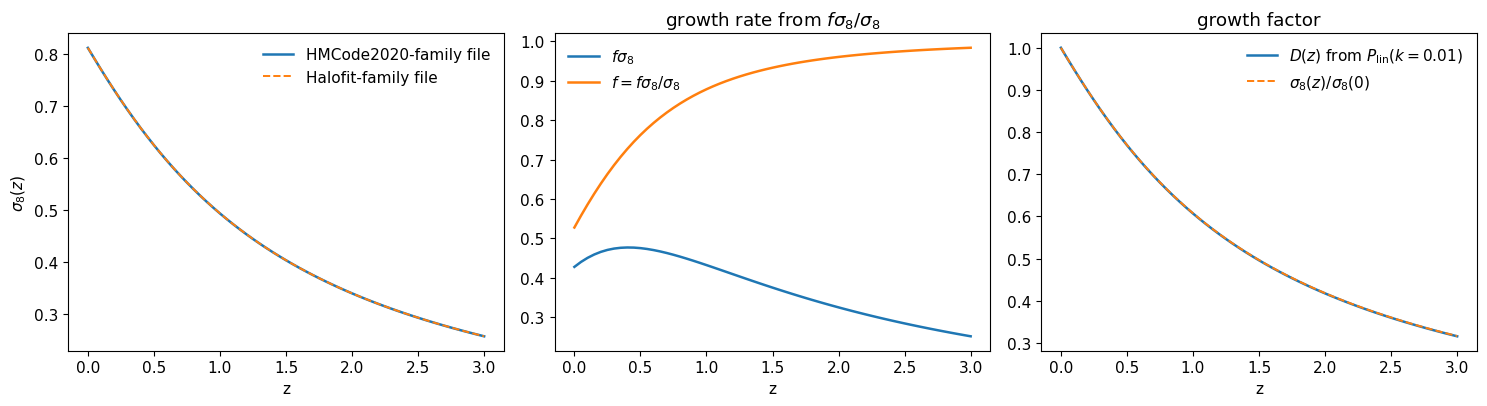

In [5]:
z_grid = np.linspace(0.0, 3.0, 61)
s8_hm = load("lcdm/hmcode/lcdm-1mass-s8-fs8.npz", probe="custom")
s8_hf = load("lcdm/halofit/halofit-lcdm-1mass-s8-fs8.npz", probe="custom")

sigma8_hm, fsigma8_hm = predict(s8_hm, **PLANCK, mnu=0.06, logT_AGN=7.6, z=z_grid).T   # logT_AGN: dummy input
sigma8_hf, fsigma8_hf = predict(s8_hf, **PLANCK, mnu=0.06, z=z_grid).T
f_growth = fsigma8_hf / sigma8_hf

# growth factor from the linear P(k) emulator at a linear scale
pk_z = predict(lin, **PLANCK, mnu=0.06, z=z_grid)
i_lin = np.argmin(np.abs(k - 0.01))
D_z = np.sqrt(pk_z[:, i_lin] / pk_z[0, i_lin])

print(f"sigma8(z=0) = {sigma8_hm[0]:.4f} (HMCode2020 file)  {sigma8_hf[0]:.4f} (Halofit file)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(z_grid, sigma8_hm, lw=1.8, label="HMCode2020-family file"); axes[0].plot(z_grid, sigma8_hf, lw=1.4, ls="--", label="Halofit-family file")
axes[0].set(xlabel="z", ylabel=r"$\sigma_8(z)$"); axes[0].legend(frameon=False)
axes[1].plot(z_grid, fsigma8_hf, lw=1.8, label=r"$f\sigma_8$"); axes[1].plot(z_grid, f_growth, lw=1.8, label=r"$f = f\sigma_8/\sigma_8$")
axes[1].set(xlabel="z", title=r"growth rate from $f\sigma_8/\sigma_8$"); axes[1].legend(frameon=False)
axes[2].plot(z_grid, D_z, lw=1.8, label=r"$D(z)$ from $P_{\rm lin}(k=0.01)$"); axes[2].plot(z_grid, sigma8_hf / sigma8_hf[0], lw=1.4, ls="--", label=r"$\sigma_8(z)/\sigma_8(0)$")
axes[2].set(xlabel="z", title="growth factor"); axes[2].legend(frameon=False)
plt.tight_layout(); plt.show()

## 5. Evaluating on your own $k$ grid

Redshift is an input, so no interpolation is needed in $z$: ask for exactly the redshifts you want. In $k$ the
emulator returns its fixed grid; interpolate $\log P$ linearly in $\log k$ onto your own grid. The grid is dense
(520 modes) so this is accurate to much better than the emulator error. Stay inside the emulator's $k$ range,
the curvature emulators start at $k = 5.3\times10^{-4}$ Mpc⁻¹ and everything else at $10^{-5}$ Mpc⁻¹.

P(k, z) on the requested grid: (3, 200)


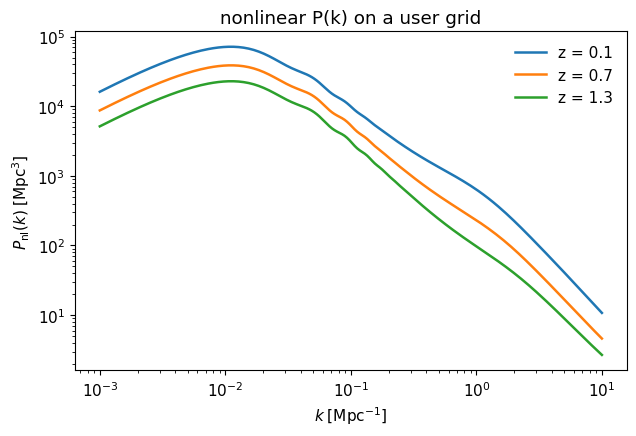

In [6]:
def pk_on_grid(emu, z_out, k_out, **cosmo):
    """P(k, z) on arbitrary redshifts z_out and wavenumbers k_out (Mpc^-1), shape (len(z_out), len(k_out))."""
    z_out = np.atleast_1d(np.asarray(z_out, dtype=float))
    k_emu = np.asarray(emu.modes)
    if k_out.min() < k_emu.min() or k_out.max() > k_emu.max():
        raise ValueError(f"k_out must lie within the emulator grid [{k_emu.min():.2e}, {k_emu.max():.2f}] Mpc^-1")
    P = predict(emu, **cosmo, z=z_out)
    return np.exp(np.array([np.interp(np.log(k_out), np.log(k_emu), np.log(row)) for row in P]))

my_k = np.logspace(-3, 1, 200)
my_z = np.array([0.1, 0.7, 1.3])
P = pk_on_grid(nl, my_z, my_k, **PLANCK, mnu=0.06, logT_AGN=7.8)
print("P(k, z) on the requested grid:", P.shape)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for row, z in zip(P, my_z):
    ax.loglog(my_k, row, lw=1.8, label=f"z = {z}")
ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm nl}(k)\;[\mathrm{Mpc}^3]$", title="nonlinear P(k) on a user grid")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 6. Batch evaluation and speed

Because every input is an array, a whole batch of cosmologies is evaluated in a single call. The first call
to a freshly loaded emulator includes JAX compilation; time the second one. On a laptop CPU the cost per
spectrum is of order microseconds in a batch, and a few hundred microseconds for one spectrum at a time
(dominated by Python overhead), to be compared with seconds for a Boltzmann code.

10000 nonlinear spectra in one call :   252.2 ms  ->  25.2 µs per spectrum
one spectrum per call             :     670 µs


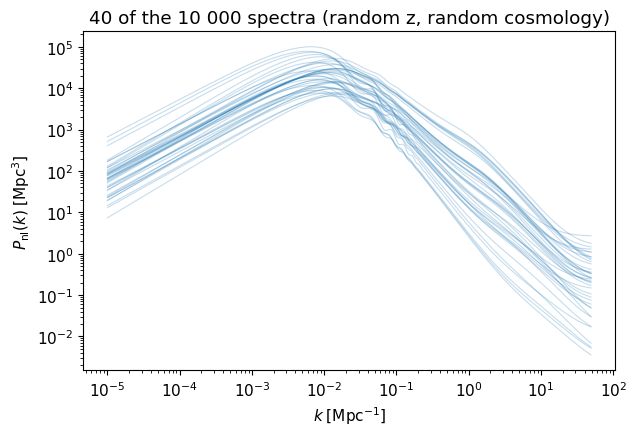

In [7]:
rng = np.random.default_rng(1)
N = 10_000
box = dict(ombh2=(0.015, 0.035), omch2=(0.05, 0.20), H0=(60, 80), ns=(0.90, 1.05),
           lnAs=(2.5, 3.5), mnu=(0.0, 0.1), logT_AGN=(7.8, 8.2), z=(0.0, 3.0))   # the paper's "standard" box
sample = {p: rng.uniform(*box[p], N) for p in box}

_ = predict(nl, **{p: sample[p][:16] for p in box})          # warm-up (compilation)
t0 = time.perf_counter(); P_batch = predict(nl, **sample); dt_batch = time.perf_counter() - t0

one = {p: sample[p][:1] for p in box}
_ = predict(nl, **one)
t0 = time.perf_counter()
for _ in range(200):
    predict(nl, **one)
dt_single = (time.perf_counter() - t0) / 200

print(f"{N} nonlinear spectra in one call : {dt_batch*1e3:7.1f} ms  ->  {dt_batch/N*1e6:.1f} µs per spectrum")
print(f"one spectrum per call             : {dt_single*1e6:7.0f} µs")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for row in P_batch[:40]:
    ax.loglog(k, row, color="C0", alpha=0.25, lw=0.8)
ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm nl}(k)\;[\mathrm{Mpc}^3]$", title="40 of the 10 000 spectra (random z, random cosmology)")
plt.tight_layout(); plt.show()

## 7. Derivatives with respect to the parameters

The emulators are JAX functions, so they are differentiable. `CosmoPowerJAX.derivative()` returns
$\partial P/\partial\theta$ for every output mode and every input (forward-mode autodiff). Below we plot the
logarithmic responses $\partial\ln P/\partial\ln\theta$ at $z = 0$; for the neutrino mass we show
$\partial\ln P/\partial\Sigma m_\nu$ in eV⁻¹, which tends to the familiar $-8\,f_\nu/\Sigma m_\nu$ on small scales.

This is the ingredient for gradient-based samplers (HMC, NUTS) and for Fisher forecasts.

dP/dtheta shape: (520, 8)


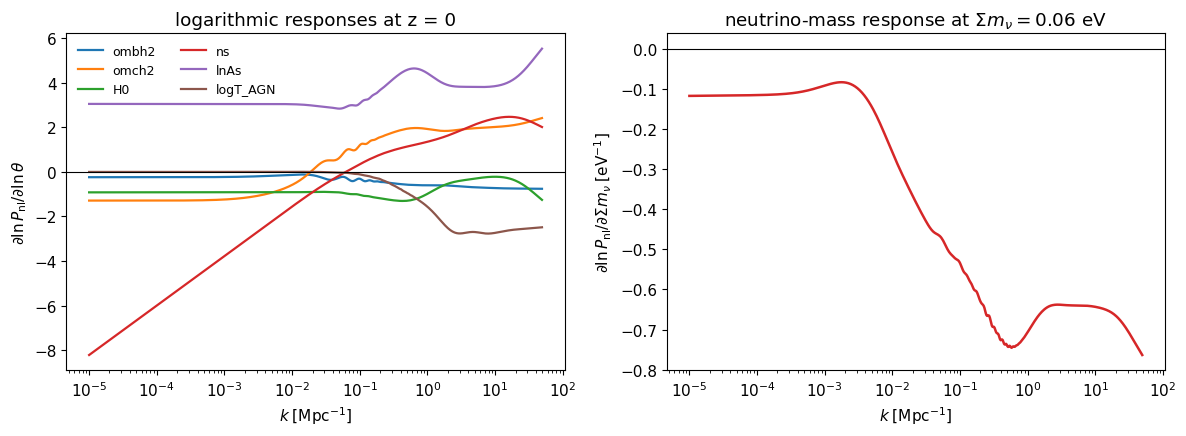

In [8]:
theta_dict = {**PLANCK, "mnu": 0.06, "logT_AGN": 7.8, "z": 0.0}
theta = np.array([theta_dict[p] for p in nl.parameters])            # inputs in the emulator's own order

dP = np.squeeze(np.asarray(nl.derivative(theta)))                   # (n_modes, n_parameters)
P0 = predict(nl, **theta_dict)[0]
print("dP/dtheta shape:", dP.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for j, p in enumerate(nl.parameters):
    if p in ("z", "mnu"):
        continue
    axes[0].semilogx(k, dP[:, j] / P0 * theta[j], lw=1.6, label=p)
axes[0].axhline(0, color="k", lw=0.8); axes[0].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$\partial\ln P_{\rm nl}/\partial\ln\theta$", title="logarithmic responses at z = 0")
axes[0].legend(frameon=False, ncol=2, fontsize=9)

j_mnu = list(nl.parameters).index("mnu")
axes[1].semilogx(k, dP[:, j_mnu] / P0, color="C3", lw=1.8)
axes[1].axhline(0, color="k", lw=0.8); axes[1].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$\partial\ln P_{\rm nl}/\partial\Sigma m_\nu\;[\mathrm{eV}^{-1}]$", title=r"neutrino-mass response at $\Sigma m_\nu = 0.06$ eV")
plt.tight_layout(); plt.show()

## 8. Staying inside the training box

**Inputs outside the training box are silently extrapolated.** CosmoPower-JAX raises no error and returns no
NaN, so a check belongs in your pipeline. The CAMB families (ΛCDM, wCDM, w0waCDM, curvature, running) are
valid over the *extended* box of the paper, reproduced below; the 1bDDM and MG boxes are in notebook `03`.

In [9]:
EXTENDED_BOX = {
    "ombh2": (0.001, 0.100), "omch2": (0.05, 0.90), "H0": (20.0, 100.0), "ns": (0.60, 1.30),
    "lnAs": (1.61, 5.00), "logT_AGN": (7.30, 8.50), "z": (0.0, 5.0),
    "w": (-3.0, 0.0), "w0": (-3.0, -0.33), "wa": (-3.0, 3.0),
    "mnu": (0.0, 1.0), "alpha_s": (-0.3, 0.3), "omk": (-0.3, 0.3),
}

def check_bounds(emu, box=EXTENDED_BOX, **params):
    """Raise if any input used by `emu` lies outside `box`."""
    bad = []
    for p in emu.parameters:
        lo, hi = box[p]
        v = np.atleast_1d(params[p])
        if v.min() < lo or v.max() > hi:
            bad.append(f"{p} = {v.min():g}..{v.max():g} outside [{lo}, {hi}]")
    if bad:
        raise ValueError("out of the training box: " + "; ".join(bad))

good = {**PLANCK, "mnu": 0.06, "logT_AGN": 7.8, "z": 0.5}
check_bounds(nl, **good)
print("in range: P_nl(k=0.1) =", f"{predict(nl, **good)[0, np.argmin(abs(k-0.1))]:.1f}", "Mpc^3")

bad = {**good, "H0": 120.0}
print("H0 = 120 still returns a number:", f"{predict(nl, **bad)[0, np.argmin(abs(k-0.1))]:.1f}", "Mpc^3  <- do not trust it")
try:
    check_bounds(nl, **bad)
except ValueError as e:
    print("check_bounds:", e)

in range: P_nl(k=0.1) = 6470.4 Mpc^3
H0 = 120 still returns a number: 4299.5 Mpc^3  <- do not trust it
check_bounds: out of the training box: H0 = 120..120 outside [20.0, 100.0]


## Where next

* `02_model_families.ipynb` — neutrino variants, wCDM / w0waCDM, HMCode2020 vs Halofit, curvature, running.
* `03_beyond_lcdm_ddm_and_mg.ipynb` — one-body decaying dark matter (including the nonlinear reconstruction) and the parameterised-gravity boosts.
* `04_cloelib_interface.ipynb` — the same emulators through the `cloelib` `Perturbations` protocol, compared with CAMB.
* The per-file inventory with inputs, outputs and grids: `../emulators/INVENTORY.md`.